# Buyer behaviour in search and recommendations

This analysis give insights on what makes a buyer click a listing on FINN. 

The analysis uses the public FINN.no slate dataset, sampled to 5% of users and processed through the project's Snowflake/dbt pipeline. All results in this notebook come from observed interactions; no simulated data is used.

I focus on three questions:

1. Do buyers click more on search results or on recommendations?
2. How much does a listing's position in the slate affect whether it is clicked?
3. How does click-through differ between categories?

**Data rules that affect the results** (found while loading the data, see the README):

- In 11.8% of slates, one item was removed from the recorded list and the items after it moved
  up one position. Those slates are left out of the position analysis.
- About one in six listings shown has a missing identity (`<UNK>`), so it has no category.
- Each buyer has many slates, so slates are not independent. Confidence intervals are computed
  by resampling buyers, not slates.

**To run:** build the dbt models first (`dbt build`), then run all cells. Results are read from
the `DEV` database; set `FINN_DATABASE=PROD` to read the production build.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from snowflake_io import database, query

DB = database()
MARTS = f"{DB}.ANALYTICS_MARTS"
INTERMEDIATE = f"{DB}.ANALYTICS_INTERMEDIATE"

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

# Colours follow the slate type everywhere in the project.
COLOURS = {"search": "#2a78d6", "recommendation": "#eb6834"}
LABELS = {"search": "Search", "recommendation": "Recommendations"}
TYPES = ["search", "recommendation"]

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e5e4df",
    "grid.linewidth": 0.8,
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "text.color": "#0b0b0b",
    "legend.frameon": False,
    "lines.linewidth": 2,
})

pd.set_option("display.float_format", "{:,.4f}".format)
print(f"Reading from {DB}")

Reading from DEV


In [2]:
RNG = np.random.default_rng(42)
N_BOOTSTRAP = 1000


def buyer_bootstrap(numerators, denominators, n=N_BOOTSTRAP, rng=RNG):
    """Ratio sum(numerators) / sum(denominators), with a 95% interval from resampling buyers.

    Each argument holds one array per estimate, all with one value per buyer in the same order,
    so estimates computed from the same resample can be compared with each other.
    """
    numerators = np.asarray(numerators, dtype=float)
    denominators = np.asarray(denominators, dtype=float)
    n_buyers = numerators.shape[-1]
    draws = np.empty((n, numerators.shape[0]))
    for i in range(n):
        sample = rng.integers(0, n_buyers, n_buyers)
        draws[i] = numerators[:, sample].sum(axis=1) / denominators[:, sample].sum(axis=1)
    point = numerators.sum(axis=1) / denominators.sum(axis=1)
    return point, draws


def interval(draws):
    return np.percentile(draws, [2.5, 97.5], axis=0)

## 1. Search results compared with recommendations

In [6]:
# import warnings
# warnings.filterwarnings("ignore", module="snowflake.connector.vendored.urllib3")
# warnings.filterwarnings("ignore", message=".*Boto3 will no longer support Python 3.9.*")

search_vs_recs = query(f"select * from {MARTS}.MART_SEARCH_VS_RECS order by slates desc")
display(search_vs_recs)

,interaction_type,slates,buyers,slates_with_click,slate_click_rate,avg_listings_shown,unknown_listing_share,avg_clicked_position,removed_item_share
0,search,1298445,95982,1048055,0.8072,9.2608,0.1740,4.6450,0.0948
1,recommendation,564509,78412,360098,0.6379,11.7778,0.1570,6.1496,0.1723


In [7]:
# Share of slates with a click, per buyer and slate type. Buyers without slates of a type
# contribute 0 to both sums for that type, so every buyer can stay in one shared resample.
per_buyer = query(f"""
    select
        user_id,
        count_if(interaction_type = 'search') as search_slates,
        count_if(interaction_type = 'search' and has_click) as search_clicks,
        count_if(interaction_type = 'recommendation') as rec_slates,
        count_if(interaction_type = 'recommendation' and has_click) as rec_clicks
    from {INTERMEDIATE}.INT_SLATES
    group by 1
""")

point, draws = buyer_bootstrap(
    [per_buyer.search_clicks, per_buyer.rec_clicks],
    [per_buyer.search_slates, per_buyer.rec_slates],
)
low, high = interval(draws)
diff_low, diff_high = np.percentile(draws[:, 0] - draws[:, 1], [2.5, 97.5])

click_rate = pd.DataFrame({
    "slate_type": TYPES,
    "slate_click_rate": point,
    "ci_low": low,
    "ci_high": high,
})
display(click_rate)
print(
    f"Buyers click a listing in {point[0]:.1%} of search slates and {point[1]:.1%} of "
    f"recommendation slates. Difference: {(point[0] - point[1]) * 100:.1f} percentage points "
    f"(95% CI {diff_low * 100:.1f} to {diff_high * 100:.1f}), from {len(per_buyer):,} buyers."
)

,slate_type,slate_click_rate,ci_low,ci_high
0,search,0.8072,0.8061,0.8082
1,recommendation,0.6379,0.6359,0.6401


Buyers click a listing in 80.7% of search slates and 63.8% of recommendation slates. Difference: 16.9 percentage points (95% CI 16.7 to 17.1), from 113,404 buyers.


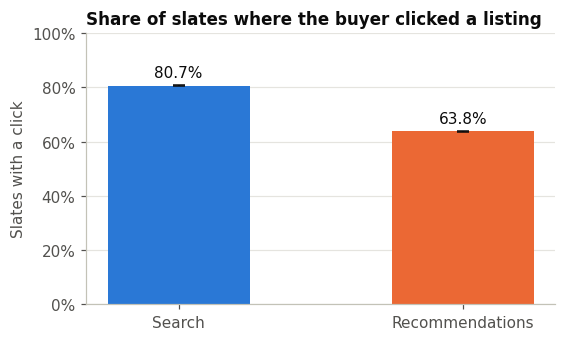

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 3.2))
x = np.arange(len(TYPES))
ax.bar(x, point, width=0.5, color=[COLOURS[t] for t in TYPES])
ax.errorbar(x, point, yerr=[point - low, high - point], fmt="none", ecolor="#0b0b0b",
            elinewidth=1.5, capsize=4)
for xi, value in zip(x, point):
    ax.text(xi, value + 0.03, f"{value:.1%}", ha="center", color="#0b0b0b")
ax.set_xticks(x, [LABELS[t] for t in TYPES])
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_ylabel("Slates with a click")
ax.grid(axis="x", visible=False)
ax.set_title("Share of slates where the buyer clicked a listing")
fig.savefig(FIGURES / "search_vs_recs_click_rate.png")
plt.show()

## 2. Position effect

Each slate gets at most one click, so in a slate with more listings every position gets a
smaller share of clicks. Positions are therefore compared **within the same slate size**. Only
slates without a removed item are used, because positions are exact only there.

In [9]:
position = query(f"select * from {MARTS}.MART_POSITION_CTR")
position = position[position.interaction_type.isin(TYPES)]

# Slate sizes to chart: a short, a medium and a long slate, if each has enough slates.
# Number of slates of a size = exposures at position 1.
slates_by_size = (
    position[position.display_position == 1]
    .groupby("slate_size")["exposures"].sum()
    .sort_values(ascending=False)
)
MIN_SLATES = 1_000
SIZES = [size for size in (5, 10, 20) if slates_by_size.get(size, 0) >= MIN_SLATES]
if not SIZES:
    SIZES = sorted(slates_by_size.head(3).index)
print("Slates per size (most common first):")
display(slates_by_size.head(10).to_frame("slates"))
print(f"Charted slate sizes: {SIZES}")

Slates per size (most common first):


,slates
slate_size,
4,231710
6,200481
3,159189
2,136046
5,120741
9,85046
8,74062
12,68787
10,66378


Charted slate sizes: [5, 10, 20]


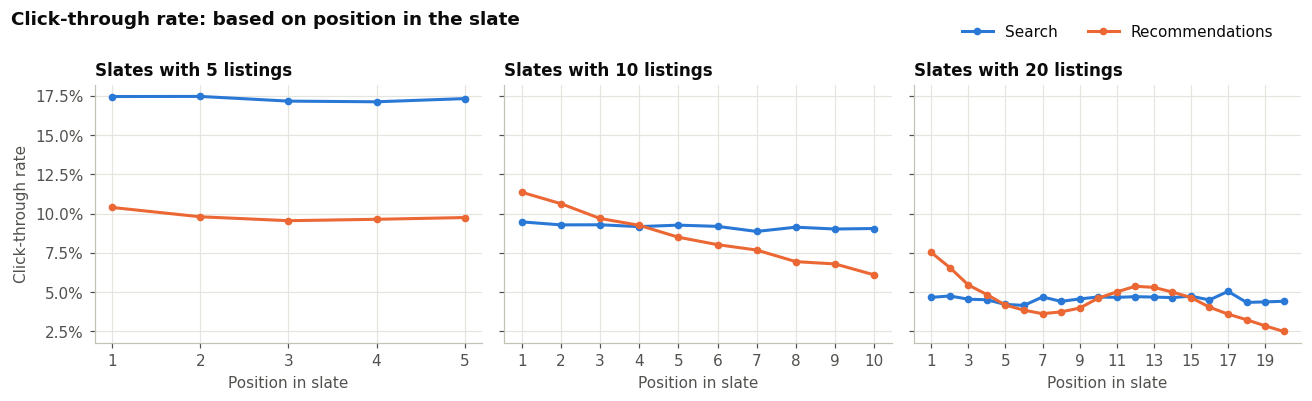

In [30]:
fig, axes = plt.subplots(1, len(SIZES), figsize=(4 * len(SIZES), 4), sharey=True)
for ax, size in zip(np.atleast_1d(axes), SIZES):
    for slate_type in TYPES:
        rows = position[(position.slate_size == size) & (position.interaction_type == slate_type)]
        rows = rows.sort_values("display_position")
        ax.plot(rows.display_position, rows.click_through_rate, color=COLOURS[slate_type],
                marker="o", markersize=4, label=LABELS[slate_type])
    ax.set_title(f"Slates with {size} listings")
    ax.set_xlabel("Position in slate")
    ax.set_xticks(range(1, size + 1, 1 if size <= 10 else 2))
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

np.atleast_1d(axes)[0].set_ylabel("Click-through rate")
handles, labels = np.atleast_1d(axes)[0].get_legend_handles_labels()
fig.suptitle("Click-through rate: based on position in the slate", x=0.01, y=0.9, ha="left", fontweight="bold")
fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.72, 0.9), ncol=2)
fig.tight_layout(rect=(0, 0, 1, 0.9))

fig.savefig(FIGURES / "position_ctr.png")
plt.show()



In [31]:
# Headline: first position against fifth position, in the most common slate size of 5 or more,
# for each slate type, with buyer-level intervals.
HEADLINE_SIZE = int(slates_by_size[slates_by_size.index >= 5].index[0])

per_buyer_position = query(f"""
    select
        user_id,
        interaction_type,
        count(*) as slates,
        count_if(clicked_display_position = 1) as clicks_position_1,
        count_if(clicked_display_position = 5) as clicks_position_5
    from {INTERMEDIATE}.INT_SLATES
    where not has_removed_item
        and n_listings_shown = {HEADLINE_SIZE}
        and interaction_type in ('search', 'recommendation')
    group by 1, 2
""")

headline_rows = []
for slate_type in TYPES:
    rows = per_buyer_position[per_buyer_position.interaction_type == slate_type]
    # Every slate of this size shows one listing at position 1 and one at position 5,
    # so the slate count is the exposure count for both positions.
    point_p, draws_p = buyer_bootstrap(
        [rows.clicks_position_1, rows.clicks_position_5],
        [rows.slates, rows.slates],
    )
    ratio = point_p[0] / point_p[1]
    ratio_low, ratio_high = np.percentile(draws_p[:, 0] / draws_p[:, 1], [2.5, 97.5])
    headline_rows.append({
        "slate_type": slate_type,
        "slates": int(rows.slates.sum()),
        "ctr_position_1": point_p[0],
        "ctr_position_5": point_p[1],
        "ratio_1_to_5": ratio,
        "ratio_ci_low": ratio_low,
        "ratio_ci_high": ratio_high,
    })

headline = pd.DataFrame(headline_rows)
display(headline)
for row in headline.itertuples():
    print(
        f"In {row.slate_type} slates with {HEADLINE_SIZE} listings, the first "
        f"listing gets {row.ratio_1_to_5:.1f} times the clicks of the fifth "
        f"(95% CI {row.ratio_ci_low:.1f} to {row.ratio_ci_high:.1f})."
    )

,slate_type,slates,ctr_position_1,ctr_position_5,ratio_1_to_5,ratio_ci_low,ratio_ci_high
0,search,149174,0.1470,0.1437,1.0228,1.0030,1.0426
1,recommendation,51307,0.1157,0.1058,1.0934,1.0531,1.1334


In search slates with 6 listings, the first listing gets 1.0 times the clicks of the fifth (95% CI 1.0 to 1.0).
In recommendation slates with 6 listings, the first listing gets 1.1 times the clicks of the fifth (95% CI 1.1 to 1.1).


Position and appeal are mixed in these numbers: FINN's ranking puts the listings it expects to
perform best at the top, so part of the drop with position is the ranking working, not the
position itself. Separating the two would need randomised positions, which this data does not
have.

## 3. Categories

Listings with a missing identity are grouped as `UNKNOWN`. The chart shows categories with at
least 10,000 exposures; the table has every category with its exposure count.

In [32]:
categories = query(f"select * from {MARTS}.MART_CATEGORY_CTR")
categories = categories[categories.interaction_type.isin(TYPES)]

table = categories.pivot_table(
    index="main_category",
    columns="interaction_type",
    values=["exposures", "click_through_rate"],
)
table = table.sort_values(("exposures", "search"), ascending=False)
display(table)

click_through_rate             exposures               
interaction_type     recommendation search recommendation         search
main_category                                                           
REAL_ESTATE                  0.0602 0.1159 1,613,806.0000 3,152,348.0000
MOTOR                        0.0639 0.0993 1,728,151.0000 2,895,888.0000
BAP                          0.0671 0.1036 1,627,366.0000 2,594,508.0000
UNKNOWN                      0.0000 0.0000 1,043,954.0000 2,092,645.0000
BOAT                         0.0734 0.1015   380,082.0000   804,435.0000
JOB                          0.0476 0.0843   254,284.0000   484,824.0000
TRAVEL                       0.0749    NaN     1,041.0000            NaN

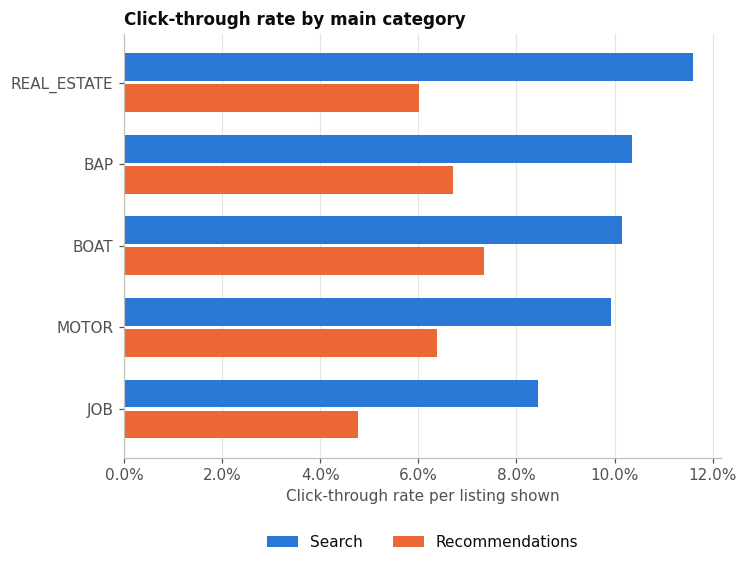

In [40]:
MIN_EXPOSURES = 10_000
chart = categories.pivot_table(index="main_category", columns="interaction_type",
                               values="click_through_rate")
exposures = categories.groupby("main_category")["exposures"].sum()
chart = chart[exposures.reindex(chart.index) >= MIN_EXPOSURES]

# UNKNOWN is left out: those listings never have a recorded click in FINN's data.
chart = chart.drop(index="UNKNOWN", errors="ignore").sort_values("search", na_position="first")

fig, ax = plt.subplots(figsize=(7, 5))
y = np.arange(len(chart))
height = 0.38
for offset, slate_type in zip([height / 2, -height / 2], TYPES):
    if slate_type in chart:
        ax.barh(y + offset, chart[slate_type].fillna(0), height=height - 0.04,
                color=COLOURS[slate_type], label=LABELS[slate_type])
ax.set_yticks(y, chart.index)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_xlabel("Click-through rate per listing shown")
ax.grid(axis="y", visible=False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
ax.set_title("Click-through rate by main category")
fig.savefig(FIGURES / "category_ctr.png")
plt.show()

Category differences are partly a slate-size effect: categories that tend to appear in long
slates get a lower rate per listing, because the single click is shared among more listings.

## Summary

The key numbers from this notebook, for the README and the dashboard.

In [41]:
summary = {
    "Buyers in sample": f"{len(per_buyer):,}",
    "Slate click rate, search": f"{point[0]:.1%} ({low[0]:.1%} to {high[0]:.1%})",
    "Slate click rate, recommendations": f"{point[1]:.1%} ({low[1]:.1%} to {high[1]:.1%})",
}
for row in headline.itertuples():
    summary[f"Position 1 vs 5, {row.slate_type} slates with {HEADLINE_SIZE} listings"] = (
        f"{row.ratio_1_to_5:.1f}x ({row.ratio_ci_low:.1f} to {row.ratio_ci_high:.1f})"
    )
pd.Series(summary).to_frame("value")

,value
Buyers in sample,"113,404"
"Slate click rate, search",80.7% (80.6% to 80.8%)
"Slate click rate, recommendations",63.8% (63.6% to 64.0%)
"Position 1 vs 5, search slates with 6 listings",1.0x (1.0 to 1.0)
"Position 1 vs 5, recommendation slates with 6 listings",1.1x (1.1 to 1.1)
